# Tasks for laboratory assignment 3

In [1]:
# imports section

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.preprocessing import PolynomialFeatures


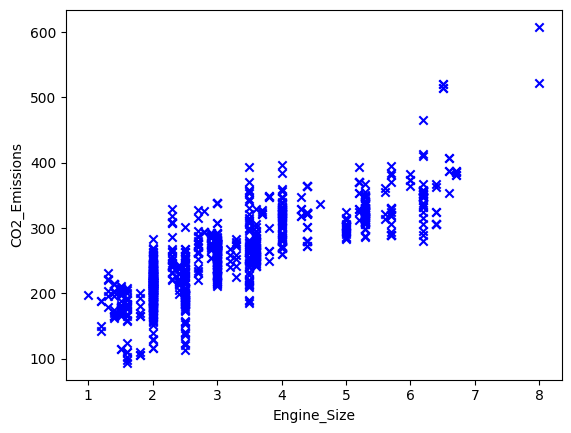

In [2]:
def build_plot(file_path, x, y):
    data = pd.read_csv(file_path)
    plt.scatter(data[x], data[y], c='blue', marker='x')
    plt.xlabel(x)
    plt.ylabel(y)
    return plt

build_plot('resources/CO2_emission.csv', 'Engine_Size', 'CO2_Emissions').show()


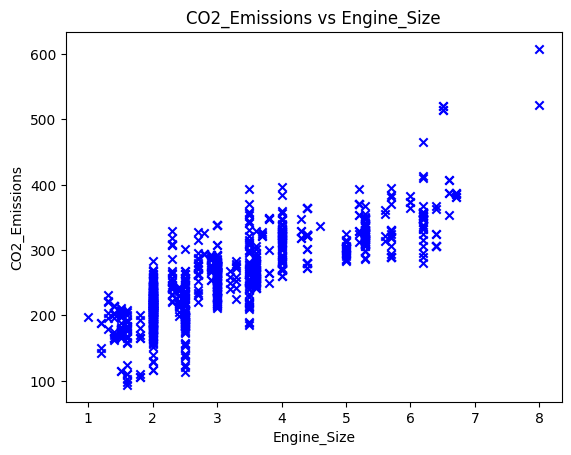

In [5]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.preprocessing import PolynomialFeatures

# Function to build scatter plot
def build_plot(file_path, x, y):
    data = pd.read_csv(file_path)
    plt.scatter(data[x], data[y], c='blue', marker='x')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x}")
    return plt

# Build and show plot
build_plot('resources/CO2_emission.csv', 'Engine_Size', 'CO2_Emissions').show()


## CO2 emissions

Process file `CO2_emission.csv`. Build a model, that would predict CO2 emissions from the size of the engine of car. Visualize model on a plot.

Choose regression model that would best fit the data. Choose the library for model implementation (sklearn, other library, custom implementation).

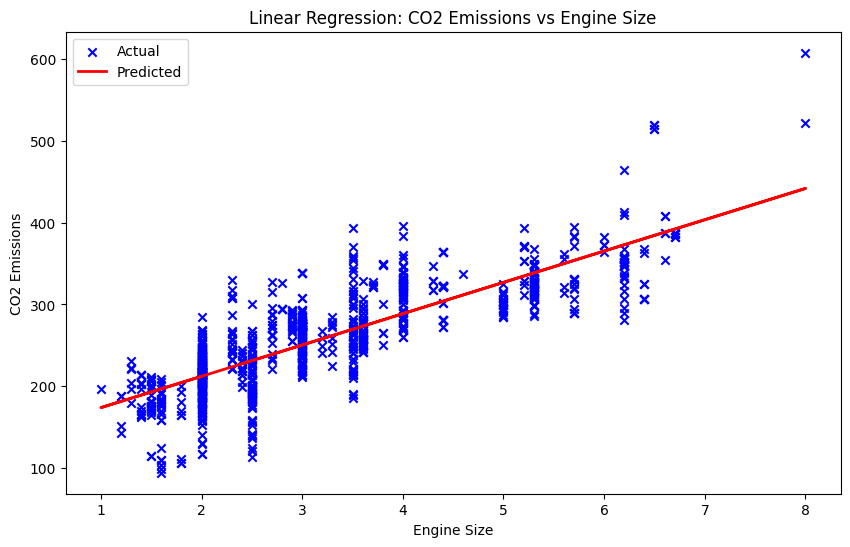

Model parameters (theta): [np.float64(135.3260546026322), np.float64(38.32301106042744)]


In [6]:
def CO2_emissions(file_path):
    """
    Build a model that predicts CO2 emissions from engine size and visualize the result.

    Args:
        file_path (str): Path to CO2_emission CSV file.

    Returns:
        list: List of model parameters (theta).
    """
    # Load data
    data = pd.read_csv(file_path)
    X = data[['Engine_Size']].values  # feature
    y = data['CO2_Emissions'].values  # target

    # Build linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict
    y_pred = model.predict(X)
    
    # Plot
    plt.figure(figsize=(10,6))
    plt.scatter(X, y, color='blue', marker='x', label='Actual')
    plt.plot(X, y_pred, color='red', linewidth=2, label='Predicted')
    plt.xlabel('Engine Size')
    plt.ylabel('CO2 Emissions')
    plt.title('Linear Regression: CO2 Emissions vs Engine Size')
    plt.legend()
    plt.show()
    
    # Return model parameters (intercept and coefficient)
    return [model.intercept_, model.coef_[0]]

# Example usage
theta = CO2_emissions('resources/CO2_emission.csv')
print("Model parameters (theta):", theta)

## Ice Cream Sales

Process file `ice_cream_selling_data.csv`. Build a model, that would predict ice cream sales based on the temperature. Visualize model on a plot.

Choose regression model that would best fit the data. Choose the library for model implementation (sklearn, other library, custom implementation).

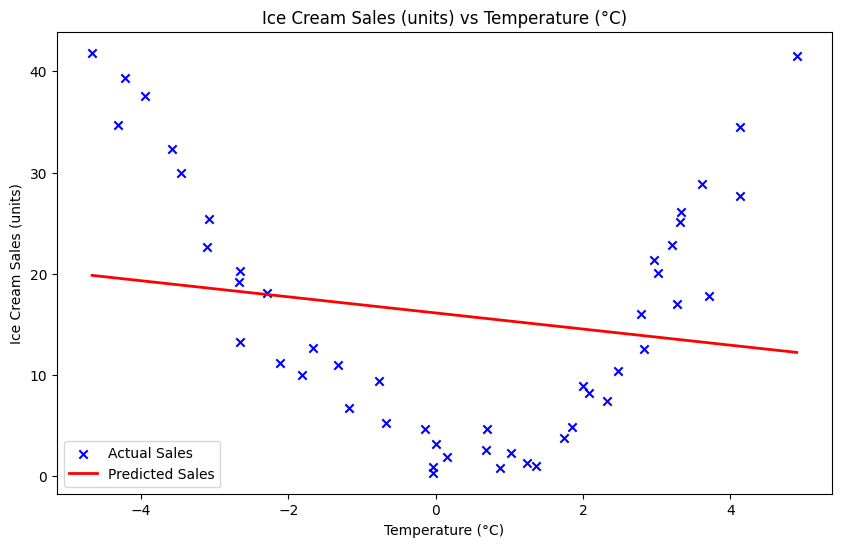

Model parameters (theta): [np.float64(16.121749391993667), np.float64(-0.7964571107159999)]


In [9]:


def ice_cream_selling(file_path):
    """
    Build a model that predicts ice cream sales based on temperature and visualize the result.
    Automatically uses the first two columns of the CSV.

    Args:
        file_path (str): Path to ice_cream_selling_data.csv

    Returns:
        list: List of model parameters [intercept, coefficient]
    """
    # Load data
    data = pd.read_csv(file_path)
    
    # Check that CSV has at least two columns
    if data.shape[1] < 2:
        raise ValueError("CSV file must have at least two columns")
    
    # Use first column as feature (X) and second as target (y)
    X = data.iloc[:, [0]].values
    y = data.iloc[:, 1].values
    
    # Build linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict
    y_pred = model.predict(X)
    
    # Plot
    plt.figure(figsize=(10,6))
    plt.scatter(X, y, color='blue', marker='x', label='Actual Sales')
    plt.plot(X, y_pred, color='red', linewidth=2, label='Predicted Sales')
    plt.xlabel(data.columns[0])
    plt.ylabel(data.columns[1])
    plt.title(f'{data.columns[1]} vs {data.columns[0]}')
    plt.legend()
    plt.show()
    
    # Return model parameters
    return [model.intercept_, model.coef_[0]]

# Example usage
theta = ice_cream_selling('resources/ice_cream_selling_data.csv')
print("Model parameters (theta):", theta)


## Electric Power Consumption

Process file `powerconsumption.csv`. Build a model, that would predict electricity consumption from the weather: temperature, humidity and wind speed. Visualize model on a plot.

Choose regression model that would best fit the data. Choose the library for model implementation (sklearn, other library, custom implementation).

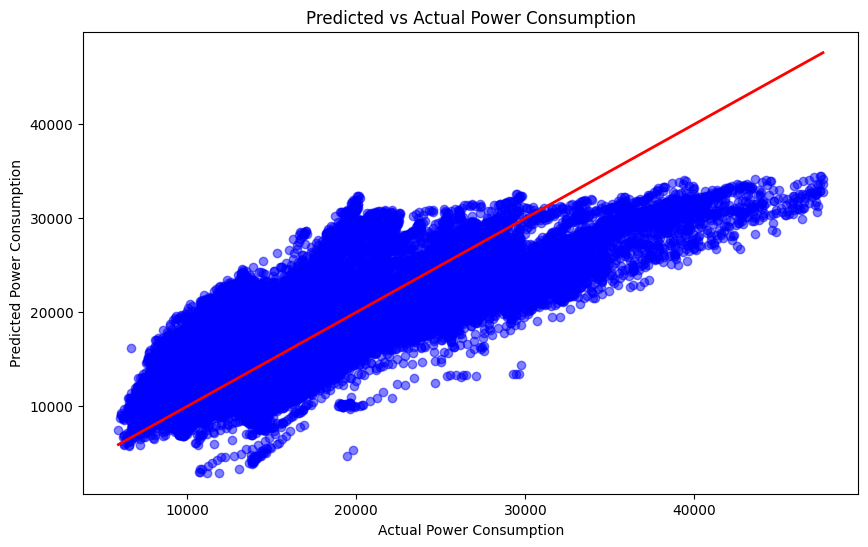

Model parameters (theta): [np.float64(-5580.328145320451), 275.1284790705829, -9.85676344116651, 203.4877954527741, -3.9700339957681523, -3.194959926480552, 0.7720693190169783, -0.2610377472744121]


In [12]:

def power_consumption(file_path):
    """
    Build a model that predicts electricity consumption from the weather: temperature, humidity, wind speed.
    Visualize predicted vs actual consumption.
    Automatically selects only numeric columns.

    Args:
        file_path (str): Path to powerconsumption.csv

    Returns:
        list: List of model parameters [intercept, coef1, coef2, ...]
    """
    # Load data
    data = pd.read_csv(file_path)
    
    # Select only numeric columns
    numeric_data = data.select_dtypes(include='number')
    
    if numeric_data.shape[1] < 2:
        raise ValueError("CSV must contain at least one feature and one target numeric column")
    
    # Use all columns except last as features, last column as target
    X = numeric_data.iloc[:, :-1].values
    y = numeric_data.iloc[:, -1].values
    
    # Build multiple linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Predict
    y_pred = model.predict(X)
    
    # Plot predicted vs actual
    plt.figure(figsize=(10,6))
    plt.scatter(y, y_pred, color='blue', alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=2)
    plt.xlabel("Actual Power Consumption")
    plt.ylabel("Predicted Power Consumption")
    plt.title("Predicted vs Actual Power Consumption")
    plt.show()
    
    # Return intercept and coefficients
    return [model.intercept_] + model.coef_.tolist()

# Example usage
theta = power_consumption('resources/powerconsumption.csv')
print("Model parameters (theta):", theta)

## Heart Conditions Predictions

Process file `heart.csv`. It has the following data:

- age - Age of the patient
- sex - Sex of the patient
- cp - Chest pain type ~ 0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic
- trtbps - Resting blood pressure (in mm Hg)
- chol - Cholestoral in mg/dl fetched via BMI sensor
- fbs - (fasting blood sugar > 120 mg/dl) ~ 1 = True, 0 = False
- restecg - Resting electrocardiographic results ~ 0 = Normal, 1 = ST-T wave normality, 2 = Left ventricular hypertrophy
- thalachh - Maximum heart rate achieved
- oldpeak - Previous peak
- slp - Slope
- caa - Number of major vessels
- thall - Thalium Stress Test result ~ (0,3)
- exng - Exercise induced angina ~ 1 = Yes, 0 = No
- output - Target variable - risk of heart attack - 1 is high chance of heart attack and 0 is low chance.

Use classification model (choose model best fitting model yourself). Choose parameters that would best fit for making a prediction on. Visualize model on a plot.

*Bonus points*: split data into train data and validation data. Validate your model.

Validation Accuracy: 0.85


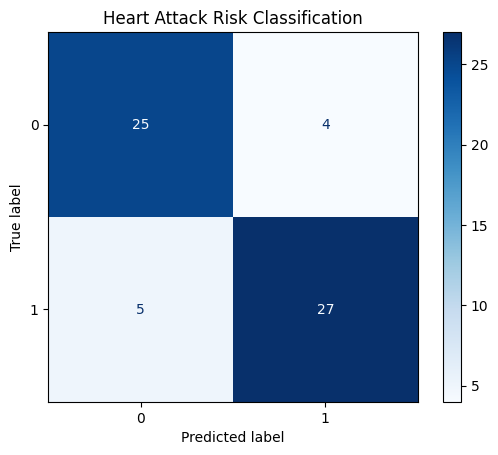

Model parameters (theta): [np.float64(0.17893699844861854), -0.08559140600023718, -0.7830855227335494, 0.8179036309655467, -0.2733068494443482, -0.17484121288174115, 0.09031166263166437, 0.2841789323126423, 0.3951308718761357, -0.5175838792013208, -0.6813963466155426, 0.4353016780808153, -0.7899552494876225, -0.5656585292886971]


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

def heart_classification(file_path):
    """
    Build a model that classifies heart attack risk (1 = high, 0 = low).
    Scales numeric features, increases max_iter, visualizes confusion matrix.

    Args:
        file_path (str): Path to heart.csv

    Returns:
        list: List of model parameters (intercept + coefficients)
    """
    # Load data
    data = pd.read_csv(file_path)
    
    # Features and target
    X = data.drop('output', axis=1)
    y = data['output']
    
    # Split into train and validation sets (80/20)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Logistic Regression with increased max_iter
    model = LogisticRegression(max_iter=5000)
    model.fit(X_train_scaled, y_train)
    
    # Predict on validation set
    y_pred = model.predict(X_val_scaled)
    
    # Accuracy
    acc = accuracy_score(y_val, y_pred)
    print(f"Validation Accuracy: {acc:.2f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Heart Attack Risk Classification")
    plt.show()
    
    # Return model parameters (intercept + coefficients)
    return [model.intercept_[0]] + model.coef_[0].tolist()

# Example usage
theta = heart_classification('resources/heart.csv')
print("Model parameters (theta):", theta)


## Additional (extra credit)

There are more files in the `resources` folder. Take a look at the. Visualize data in these files. Choose ML algorithm for building a model and making predictions for new data. Visualize the model.